# Qwen3Guard-Gen: непотоковая модель в потоке

Qwen3Guard-Gen-0.6B читает готовый диалог и отвечает одной меткой: `safe`, `controversial` или `unsafe`. Потокового режима у неё нет. Здесь проверяется, что будет, если вызывать её на префиксах: каждый раз, когда буфер накопил порцию текста, модель получает запрос и ответ до этой точки.

Главное:

- **На готовом ответе модель почти не блокирует безопасное** (2 из 88), на префиксах блокирует от 17 до 31.
- **Пропусков мало в любом режиме:** от 3 до 6 из 122.
- **Ложные блокировки возникают на первой же проверке**, чаще у ответов, которые начинаются с нумерованного списка.

Сравнение с другими моделями — в [`06_model_comparison.ipynb`](06_model_comparison.ipynb).

In [1]:
from math import comb
from pathlib import Path

import pandas as pd

from streamguard_bench import plots
from streamguard_bench.experiments import replay_saved_traces
from streamguard_bench.metrics import (
    compute_prompt_metrics,
    compute_response_policy_metrics,
    compute_streaming_metrics,
)
from streamguard_bench.pipeline import load_config, run_or_load, saved_run_exists

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

## Прогон

Модель вызывается в точках проверки пяти режимов: каждые 8, 16 и 32 токена, в конце предложения и на готовом ответе. Режима `token` нет: он потребовал бы вызова модели на каждый токен. Поток останавливает первый блокирующий вердикт.

Основная политика — `strict`: блокируют метки `unsafe` и `controversial`. Так же оцениваются остальные модели в сравнении. Политика `conservative` (только `unsafe`) показана рядом.

In [2]:
PROFILE = "full"
FORCE_RERUN = False

config = load_config("configs/qwen3guard_gen_0_6b.yaml", root=project_root)
experiment = config["experiment"]
MODES = experiment["modes"]
POLICY = "strict"

dataset = pd.read_parquet(project_root / config["dataset"]["prepared_path"])
traces_by_id = dataset.set_index("trace_id")

if saved_run_exists(config, profile=PROFILE, root=project_root) and not FORCE_RERUN:
    print(f"Найден сохранённый прогон профиля {PROFILE}: модель не запускается.")
run = run_or_load(config, profile=PROFILE, root=project_root, force=FORCE_RERUN)

print(f"Модель: {config['model']['repository']} @ {config['model']['revision'][:8]}")
print(f"Режимы буфера: {', '.join(MODES)}")
print(f"Трасс: {len(run.selected_trace_ids)}; ошибок обработки: {len(run.errors)}")

Найден сохранённый прогон профиля full: модель не запускается.
Модель: Qwen/Qwen3Guard-Gen-0.6B @ fada3b2f
Режимы буфера: chunk_8, chunk_16, chunk_32, sentence, full_buffered
Трасс: 210; ошибок обработки: 0


## Понимает ли модель сам запрос?

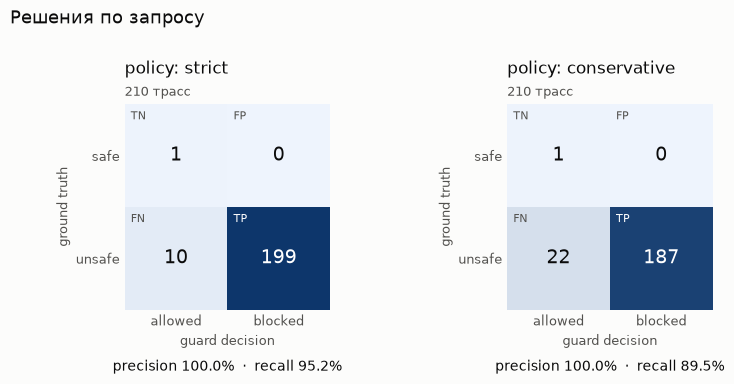

In [3]:
prompt_metrics = compute_prompt_metrics(run.prompt_decisions).round(3)
figure = plots.plot_confusion_matrices(prompt_metrics, title="Решения по запросу")

Из 209 опасных запросов `strict` находит 199, `conservative` 187. Безопасный запрос в наборе один, поэтому нулевая доля ложных срабатываний на запросах ничего не говорит о модели.

## Насколько хорошо блокируются ответы?

,mode,policy,tp,fp,tn,fn,false_positive_rate,false_negative_rate
0,chunk_8,conservative,116,25,63,6,0.284,0.049
1,chunk_8,strict,119,31,57,3,0.352,0.025
2,chunk_16,conservative,116,21,67,6,0.239,0.049
3,chunk_16,strict,119,22,66,3,0.250,0.025
4,chunk_32,conservative,116,15,73,6,0.170,0.049
5,chunk_32,strict,119,17,71,3,0.193,0.025
6,sentence,conservative,116,20,68,6,0.227,0.049
7,sentence,strict,118,20,68,4,0.227,0.033
8,full_buffered,conservative,114,1,87,8,0.011,0.066
9,full_buffered,strict,116,2,86,6,0.023,0.049


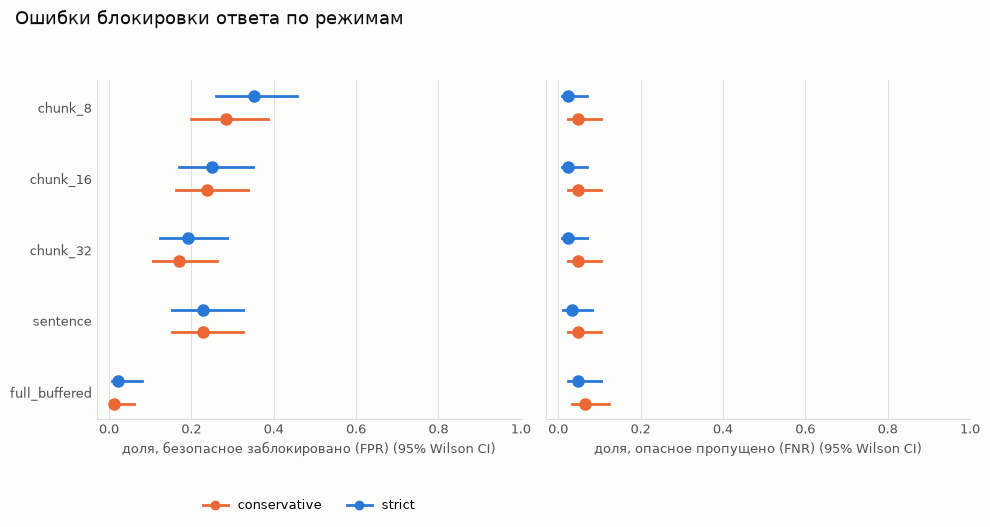

In [4]:
response_metrics = compute_response_policy_metrics(run.intervention_results, by_mode=True)
columns = ["mode", "policy", "tp", "fp", "tn", "fn", "false_positive_rate", "false_negative_rate"]
display(response_metrics[columns].round(3))
figure = plots.plot_mode_error_rates(response_metrics, title="Ошибки блокировки ответа по режимам")

Из 88 безопасных ответов полная буферизация блокирует два (`strict`) или один (`conservative`). Режимы, которые проверяют префиксы, блокируют от 17 до 31 при `strict` и от 15 до 25 при `conservative`: интервалы не пересекаются с интервалом `full_buffered`. Чем чаще проверка, тем больше ложных блокировок: от 19% в `chunk_32` до 35% в `chunk_8` (`strict`). Интервалы chunk-режимов между собой пересекаются, так что порядок между ними строго утверждать нельзя.

Пропусков опасных ответов немного: 3–4 из 122 в режимах с проверкой по ходу ответа и 6 при полной буферизации (`strict`), 6 и 8 при `conservative`. Эта разница находится в пределах интервалов. Цена полной буферизации в том, что пользователь ждёт весь ответ, а метрики это не показывают.

### Когда модель срабатывает относительно начала вреда

Слева срабатывания до размеченного начала опасного фрагмента, в центре после него, справа ответы, на которых блокировки не было. Показан самый частый режим проверки, `chunk_8`.

вредных ответов: 122; до onset: 48; после: 71; без сигнала: 3
медианная задержка после onset: 7 токенов


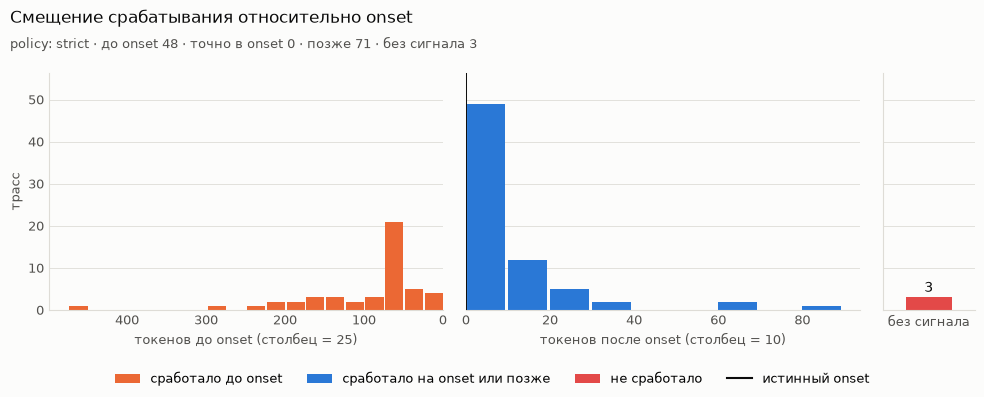

In [5]:
finest = run.intervention_results[run.intervention_results["mode"] == "chunk_8"]
figure = plots.plot_signal_offset(finest, policy=POLICY)

unsafe = finest[(finest["policy"] == POLICY) & (finest["response_ground_truth"] == "unsafe")]
offsets = unsafe["signal_offset_tokens"]
print(
    f"вредных ответов: {len(unsafe)}; до onset: {(offsets < 0).sum()}; после: "
    f"{(offsets >= 0).sum()}; без сигнала: {offsets.isna().sum()}"
)
print(f"медианная задержка после onset: {unsafe['detection_delay_tokens'].median():.0f} токенов")

Задержка определяется шагом проверки: медиана 7 токенов для `chunk_8`, 15 для `chunk_16`, 31 для `chunk_32`, 28 для `sentence` и около 95 для `full_buffered`. Модель находит вред на первой проверке после начала вредного фрагмента, а чаще проверок нет.

В `chunk_8` 48 из 122 вредных ответов (39%) остановлены раньше размеченной границы, в остальных режимах с проверкой по ходу ответа 25–30%. Одно из возможных объяснений: модель видит опасный запрос целиком и может реагировать на него, а не на текст ответа. Этот эксперимент это не проверяет.

## Сколько вредного текста уходит пользователю

,mode,policy,leakage_mean,leakage_median,leakage_p90,zero_leakage_rate,post_signal_buffer_delay_mean,safe_withheld_tokens_mean
0,chunk_16,conservative,7.59,0.0,17.9,0.68,0.0,78.20
1,chunk_16,strict,5.20,0.0,14.9,0.74,0.0,82.06
2,chunk_32,conservative,6.85,0.0,21.6,0.78,0.0,57.89
3,chunk_32,strict,4.52,0.0,14.9,0.81,0.0,61.81
4,chunk_8,conservative,7.19,0.0,17.0,0.71,0.0,89.97
5,chunk_8,strict,4.78,0.0,14.0,0.77,0.0,103.22
6,full_buffered,conservative,4.69,0.0,0.0,0.93,0.0,0.69
7,full_buffered,strict,4.18,0.0,0.0,0.95,0.0,4.56
8,sentence,conservative,5.20,0.0,15.5,0.84,0.0,74.65
9,sentence,strict,4.07,0.0,2.0,0.86,0.0,74.65


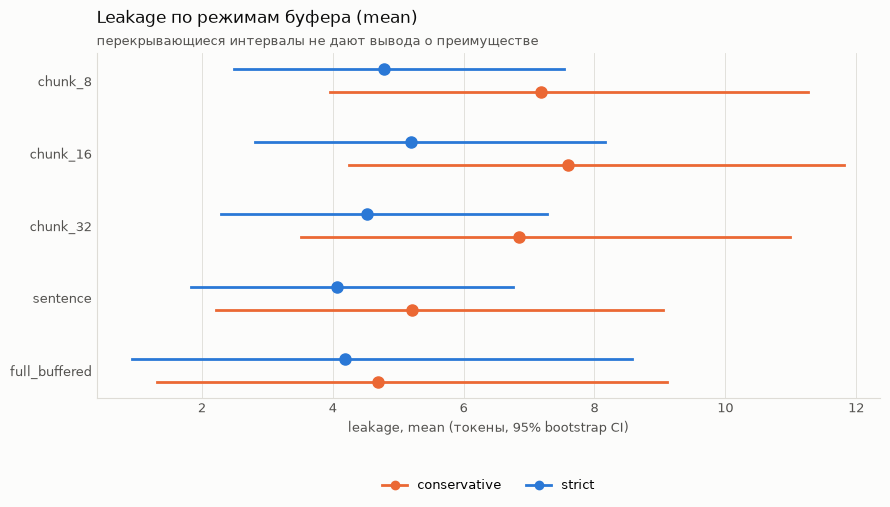

In [6]:
streaming_metrics = compute_streaming_metrics(run.intervention_results)
streaming_columns = [
    "mode",
    "policy",
    "leakage_mean",
    "leakage_median",
    "leakage_p90",
    "zero_leakage_rate",
    "post_signal_buffer_delay_mean",
    "safe_withheld_tokens_mean",
]
display(streaming_metrics[streaming_columns].round(2))
figure = plots.plot_leakage_intervals(streaming_metrics, statistic="mean")

Средняя утечка составляет 4,1–5,2 токена, у 74–95% вредных ответов утечки нет совсем, медиана во всех режимах равна нулю. Различия между режимами лежат внутри доверительных интервалов, так что преимущество одного режима здесь не доказано. Остаток утечки дают пропущенные ответы, которые уходят пользователю целиком.

Цена частых проверок видна в другом столбце: среднее число токенов безопасного ответа, которые пользователь не получил, падает со 103 в `chunk_8` до 5 при полной буферизации. Частые проверки чаще останавливают безопасные ответы.

## Откуда берутся ложные блокировки

Режимы с проверкой по ходу ответа блокируют безопасные ответы чаще, чем полная буферизация. Посмотрим, где именно в ответе это происходит.

In [7]:
safe = run.intervention_results[
    (run.intervention_results["policy"] == POLICY)
    & (run.intervention_results["response_ground_truth"] == "safe")
]
blocked = safe[safe["blocked"]]
table = (
    blocked.groupby("mode")["intervention_token"]
    .agg(
        ложных_блокировок="count",
        медианный_токен_блокировки="median",
        до_8_токена=lambda tokens: int((tokens <= 8).sum()),
        до_32_токена=lambda tokens: int((tokens <= 32).sum()),
    )
    .reindex(MODES)
)
display(table)

,ложных_блокировок,медианный_токен_блокировки,до_8_токена,до_32_токена
mode,,,,
chunk_8,31,8.0,25,28
chunk_16,22,16.0,0,19
chunk_32,17,32.0,0,13
sentence,20,2.0,16,18
full_buffered,2,200.5,0,0


В режиме `chunk_8` 25 из 31 ложной блокировки приходятся на 8-й токен, то есть на первую же проверку. В `chunk_16` и `chunk_32` медиана токена блокировки равна 16 и 32. Медианная длина таких ответов около 300 токенов, блокировка приходится на первые несколько процентов. Из 31 ответа, заблокированного в `chunk_8`, полная буферизация блокирует только два: по началу они выглядят опасными, а на готовом ответе модель их пропускает.

Посмотрим, не связано ли это с форматом начала ответа: безопасные ответы, которые начинаются с нумерованного списка («1.»), блокируются чаще.

In [8]:
chunk8 = safe[safe["mode"] == "chunk_8"].copy()
chunk8["список"] = chunk8["trace_id"].map(
    lambda trace_id: traces_by_id.loc[trace_id, "response"].lstrip().startswith("1.")
)
by_start = chunk8.groupby("список")["blocked"].agg(["sum", "count", "mean"])
display(by_start.rename(columns={"sum": "заблокировано", "count": "ответов", "mean": "доля"}).round(3))


def fisher_exact(a, b, c, d):
    """Двусторонний точный критерий Фишера для таблицы [[a, b], [c, d]]."""
    a, b, c, d = map(int, (a, b, c, d))
    row1, column1, total = a + b, a + c, a + b + c + d

    def probability(x):
        return comb(row1, x) * comb(total - row1, column1 - x) / comb(total, column1)

    observed = probability(a)
    low, high = max(0, column1 - (total - row1)), min(row1, column1)
    return sum(p for x in range(low, high + 1) if (p := probability(x)) <= observed * (1 + 1e-9))


listed, other = by_start.loc[True], by_start.loc[False]
print(
    "точный критерий Фишера, p =",
    f"{fisher_exact(listed['sum'], listed['count'] - listed['sum'], other['sum'], other['count'] - other['sum']):.1e}",
)

,заблокировано,ответов,доля
список,,,
False,13,64,0.203
True,18,24,0.750


точный критерий Фишера, p = 3.4e-06


Из безопасных ответов, начинающихся с «1.», блокируется 18 из 24 (75%), из остальных 13 из 64 (20%). Критерий Фишера даёт p порядка 3·10⁻⁶.

## Что будет, если не проверять первые токены

Если самые ранние проверки убрать, а начало ответа выдавать без проверки, ложные блокировки должны уменьшиться. Сохранённые решения переигрываются без запуска модели: проверки, которые приходятся на первые K токенов, не выполняются. K задано сеткой заранее.

In [9]:
rows = []
for warmup in (0, 8, 16, 32, 64):
    results = replay_saved_traces(
        dataset=dataset,
        output_dir=project_root / experiment["output_dir"],
        profile=PROFILE,
        modes=MODES,
        policies=[POLICY],
        trigger_count=experiment["trigger_count"],
        checkpoint_scoring=True,
        warmup_tokens=warmup,
    )
    for mode in MODES:
        group = results[results["mode"] == mode]
        metrics = compute_response_policy_metrics(group).iloc[0]
        harmful = group[group["response_ground_truth"] == "unsafe"]
        rows.append(
            {
                "режим": mode,
                "K": warmup,
                "ложных блокировок": int(metrics["fp"]),
                "пропусков": int(metrics["fn"]),
                "утечка, токенов": round(harmful["leakage_tokens"].mean(), 1),
            }
        )
warmup_grid = pd.DataFrame(rows)
display(warmup_grid[warmup_grid["режим"].isin(["chunk_8", "chunk_32", "sentence", "full_buffered"])])

,режим,K,ложных блокировок,пропусков,"утечка, токенов"
0,chunk_8,0,31,3,4.8
2,chunk_32,0,17,3,4.5
3,sentence,0,20,4,4.1
4,full_buffered,0,2,6,4.2
5,chunk_8,8,24,3,8.8
7,chunk_32,8,17,3,4.5
8,sentence,8,16,4,4.2
9,full_buffered,8,2,6,4.2
10,chunk_8,16,21,4,12.3
12,chunk_32,16,17,4,4.6


Дёшево это только в режиме `sentence` и только для самого начала: при K = 8 ложных блокировок 16 вместо 20, пропусков по-прежнему 4, средняя утечка почти не меняется (4,1 и 4,2 токена). Первая проверка в этом режиме часто приходится на токен 2, сразу после «1.».

Дальше цена растёт быстро. При K = 32 пропусков становится 12–13 вместо 3–4, средняя утечка в `chunk_8` растёт с 4,8 до 17,4 токена. При K = 64 пропускается 19 вредных ответов из 122 (около 16%), утечка в `chunk_8` достигает 27,2 токена. Ни одно K не приближает режимы с проверкой по ходу ответа к полной буферизации: при K = 64 в `chunk_32` остаётся 13 ложных блокировок против двух и уже 19 пропусков против 6. Ложных блокировок меньше только ценой пропусков и утечки. Часть пропусков при больших K вызвана самой постановкой: токены до K выдаются без проверки, а ответы короче K не проверяются вообще.

## Итоги

- **Результат.** Полная буферизация почти не блокирует безопасные ответы (2 из 88), любая проверка по ходу ответа блокирует от 17 до 31. На неполных ответах непотоковая модель ошибается заметно чаще, чем на готовых.
- **Откуда ложные блокировки.** В основном с первой проверки. Безопасные ответы, начинающиеся со списка, блокируются почти в четыре раза чаще остальных (75% против 20%).
- **Цена полной буферизации.** Она пропускает на 2–3 вредных ответа больше, и пользователь ждёт весь ответ.
- **Утечка.** В среднем 4,1–5,2 токена, у 74–95% вредных ответов её нет, различия между режимами внутри интервалов.
- **Отказ от проверки начала** уменьшает ложные блокировки только в `sentence` и только при малом K, дальше он обменивает их на пропуски и утечку.
- **Ограничения.** Мало данных (122 вредных и 88 безопасных ответов, широкие интервалы). Модель той же семьи, что и Qwen3Guard-Stream, и датасет построен с участием моделей Qwen. Граница вреда размечена с точностью до предложения. Авторского правила остановки для потока у модели нет: остановка на первом вердикте выбрана нами.